## 1. Imports and Setup

Importing necessary libraries and setting up the environment for the facial expression recognition system.


In [ ]:
import os, re, glob, json, time, random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Any, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from PIL import Image

# ===== Utils
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ===== Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

# ===== EDIT THIS: dataset paths in Drive
ROOT = "/content/drive/MyDrive/Dataset"  # <-- change if needed
ANN  = os.path.join(ROOT, "annotations")
IMGS = os.path.join(ROOT, "images")

# Where to save outputs
SAVE_DIR = "/content/drive/MyDrive/deep_temp1_runs"
os.makedirs(SAVE_DIR, exist_ok=True)

print("ANN exists?", os.path.exists(ANN))
print("IMGS exists?", os.path.exists(IMGS))


Device: cuda
Mounted at /content/drive
ANN exists? True
IMGS exists? True


## 2. Dataset Processing and Metadata Generation

Building metadata from the .npy annotation files and creating train/test splits for the facial expression dataset.


In [ ]:
def find_image_recursive(img_dir: str, stem: str):
    # Try common extensions (case-insensitive), then recursive search anywhere under img_dir
    for ext in (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPG", ".PNG", ".JPEG", ".BMP", ".WEBP"):
        p = os.path.join(img_dir, stem + ext)
        if os.path.isfile(p):
            return p
    hits = glob.glob(os.path.join(img_dir, "**", stem + ".*"), recursive=True)
    return hits[0] if hits else None

def build_meta_from_npy(ann_dir: str, img_dir: str, out_dir: str, test_size=0.2, seed=42, debug_max=10):
    print(f"[INFO] ann_dir = {ann_dir}")
    print(f"[INFO] img_dir = {img_dir}")

    exp_files = glob.glob(os.path.join(ann_dir, "*_exp.npy"))
    print(f"[INFO] Found *_exp.npy files: {len(exp_files)}")
    if len(exp_files) == 0:
        raise FileNotFoundError("No *_exp.npy files found. Check ANN path and that annotations exist.")

    # Accept any stem (numeric or not)
    id_pat = re.compile(r"(.+?)_exp\.npy$", re.IGNORECASE)
    ids = []
    for f in exp_files:
        m = id_pat.search(os.path.basename(f))
        if m: ids.append(m.group(1))
    ids = sorted(set(ids))
    print(f"[INFO] Unique IDs parsed: {len(ids)} (first 5: {ids[:5]})")

    rows, missing = [], []
    miss_counts = {"no_val":0, "no_aro":0, "no_img":0, "no_exp":0}

    def load_scalar(pth):
        arr = np.load(pth, allow_pickle=True)
        if np.isscalar(arr): return float(arr)
        try: return float(arr.item())
        except Exception: return float(np.ravel(arr)[0])

    for sid in ids:
        exp_path = os.path.join(ann_dir, f"{sid}_exp.npy")
        val_path = os.path.join(ann_dir, f"{sid}_val.npy")
        aro_path = os.path.join(ann_dir, f"{sid}_aro.npy")
        lnd_path = os.path.join(ann_dir, f"{sid}_lnd.npy")

        ok_exp = os.path.isfile(exp_path)
        ok_val = os.path.isfile(val_path)
        ok_aro = os.path.isfile(aro_path)
        img_path = find_image_recursive(img_dir, sid)

        if not ok_exp or not ok_val or not ok_aro or not img_path:
            reason = []
            if not ok_exp: reason.append("exp"); miss_counts["no_exp"] += 1
            if not ok_val: reason.append("val"); miss_counts["no_val"] += 1
            if not ok_aro: reason.append("aro"); miss_counts["no_aro"] += 1
            if not img_path: reason.append("img"); miss_counts["no_img"] += 1
            missing.append((sid, "+".join(reason)))
            continue

        try:
            exp = int(load_scalar(exp_path))
            val = float(load_scalar(val_path))
            aro = float(load_scalar(aro_path))
        except Exception as e:
            missing.append((sid, f"read_error:{e}")); continue

        rows.append({
            "id": sid,
            "filename": os.path.relpath(img_path, start=img_dir).replace("\\", "/"),
            "expression": exp,
            "valence": val,
            "arousal": aro,
            "landmarks_path": (f"{sid}_lnd.npy" if os.path.isfile(lnd_path) else "")
        })

    print(f"[INFO] Indexed rows: {len(rows)}")
    if missing:
        print(f"[WARN] Skipped {len(missing)}. Breakdown: {miss_counts}")
        for i, (sid, why) in enumerate(missing[:debug_max]):
            print(f"  - miss[{i}] id={sid} reason={why}")
        if len(missing) > debug_max:
            print(f"  ... (+{len(missing)-debug_max} more)")

    if len(rows) == 0:
        raise RuntimeError("No valid samples indexed. Check naming & paths.")

    df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
    df = df[(df["valence"] > -2) & (df["arousal"] > -2)].reset_index(drop=True)
    print(f"[INFO] After filtering (val/aro != -2): {len(df)}")

    train_df, test_df = train_test_split(
        df, test_size=test_size, random_state=seed,
        stratify=df["expression"] if df["expression"].nunique()>1 else None
    )

    Path(out_dir).mkdir(parents=True, exist_ok=True)
    train_csv = os.path.join(out_dir, "train_meta.csv")
    test_csv  = os.path.join(out_dir, "test_meta.csv")
    train_df.to_csv(train_csv, sep=";", index=False)
    test_df.to_csv(test_csv, sep=";", index=False)
    print("Wrote:", train_csv, "and", test_csv)
    print("[INFO] Train head():"); display(train_df.head(3))
    print("[INFO] Test head():"); display(test_df.head(3))
    return train_csv, test_csv

# Build (or reuse) CSVs
train_meta_csv = os.path.join(ANN, "train_meta.csv")
test_meta_csv  = os.path.join(ANN, "test_meta.csv")
if not (os.path.exists(train_meta_csv) and os.path.exists(test_meta_csv)):
    train_meta_csv, test_meta_csv = build_meta_from_npy(ANN, IMGS, ANN, test_size=0.2)

# Class weights (global)
class_weights = None
try:
    train_df_for_weights = pd.read_csv(train_meta_csv, sep=';')
    counts = train_df_for_weights['expression'].value_counts().sort_index()
    freq = counts.values.astype(float)
    inv = 1.0 / np.clip(freq, 1.0, None)
    class_weights = torch.tensor(inv / inv.sum() * len(inv), dtype=torch.float32)
    print("Class weights:", class_weights.tolist())
except Exception as e:
    print("Could not compute class weights:", e)


Class weights: [0.9996868371963501, 0.9996868371963501, 0.9996868371963501, 0.9996868371963501, 0.9996868371963501, 0.9996868371963501, 0.9996868371963501, 1.0021922588348389]


## 3. Dataset Class and Data Augmentation

Implementing the custom dataset class for facial expression data and defining data augmentation strategies including RandAugment and RandomErasing.


In [ ]:
# RandAugment (if available) + RandomErasing
try:
    from torchvision.transforms import RandAugment, RandomErasing
    HAS_RANDAUG = True
except Exception:
    HAS_RANDAUG = False
    RandomErasing = transforms.RandomErasing

class AffectDataset(Dataset):
    def __init__(self, img_root: str, meta_csv: str, transform=None):
        self.img_root = img_root
        self.df = pd.read_csv(meta_csv, sep=';')
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_root, row["filename"])).convert("RGB")
        if self.transform: img = self.transform(img)
        y_cls = int(row["expression"])
        y_va  = np.array([row["valence"], row["arousal"]], dtype=np.float32)
        return img, torch.tensor(y_cls, dtype=torch.long), torch.tensor(y_va, dtype=torch.float32)

def build_transforms(img_size=224):
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
        transforms.RandomHorizontalFlip(p=0.5),
        (RandAugment(num_ops=2, magnitude=9) if HAS_RANDAUG else transforms.ColorJitter(0.15, 0.15, 0.1, 0.02)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3))
    ])
    val_tf = transforms.Compose([
        transforms.Resize(int(img_size*1.15)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    return train_tf, val_tf


## 4. Evaluation Metrics

Implementing comprehensive evaluation metrics for both categorical classification and continuous domain regression tasks.


In [ ]:
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat)**2)))
def pearson_corr(y, yhat):
    if np.std(y)<1e-8 or np.std(yhat)<1e-8: return 0.0
    r,_ = pearsonr(y, yhat); return float(r)
def sagr(y, yhat): return float(np.mean(np.sign(y)==np.sign(yhat)))
def ccc(y, yhat):
    y, yhat = y.astype(float), yhat.astype(float)
    mu1, mu2 = np.mean(y), np.mean(yhat)
    v1, v2 = np.var(y), np.var(yhat)
    cov = np.mean((y-mu1)*(yhat-mu2))
    denom = v1+v2+(mu1-mu2)**2
    return float((2*cov)/denom) if denom>1e-12 else 0.0

def krippendorff_alpha_nominal(ratings: np.ndarray) -> float:
    valid = ~np.isnan(ratings)
    if ratings.shape[1] < 2: return np.nan
    Do, n_items = 0.0, 0
    categories = np.unique(ratings[valid])
    for i in range(ratings.shape[0]):
        row = ratings[i]; row = row[~np.isnan(row)]; m = len(row)
        if m < 2: continue
        n_items += 1
        disagree = 0; total_pairs = m*(m-1)
        for a in row: disagree += np.sum(row != a)
        Do += disagree / total_pairs
    Do = Do / n_items if n_items>0 else np.nan
    all_vals = ratings[valid]
    counts = {c: np.sum(all_vals==c) for c in categories}
    n = sum(counts.values())
    De = 1.0 - sum((v/n)**2 for v in counts.values())
    if De == 0: return np.nan
    return 1.0 - Do/De

def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> Dict[str, Any]:
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average='macro'),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
    }
    R = np.vstack([y_true, y_pred]).T.astype(float)
    out["krippendorff_alpha_nominal"] = krippendorff_alpha_nominal(R)

    classes = np.unique(y_true)
    y_true_ovr = label_binarize(y_true, classes=classes)
    try:
        out["roc_auc_ovr_macro"] = roc_auc_score(y_true_ovr, y_prob[:, classes], average='macro', multi_class='ovr')
    except Exception:
        out["roc_auc_ovr_macro"] = float('nan')
    try:
        ap = [average_precision_score(y_true_ovr[:, i], y_prob[:, c]) for i, c in enumerate(classes)]
        out["pr_auc_macro"] = float(np.nanmean(ap))
    except Exception:
        out["pr_auc_macro"] = float('nan')
    return out

def va_metrics(v_true, v_pred, a_true, a_pred) -> Dict[str,float]:
    return {
        "val_rmse": rmse(v_true, v_pred),
        "aro_rmse": rmse(a_true, a_pred),
        "val_r": pearson_corr(v_true, v_pred),
        "aro_r": pearson_corr(a_true, a_pred),
        "val_sagr": sagr(v_true, v_pred),
        "aro_sagr": sagr(a_true, a_pred),
        "val_ccc": ccc(v_true, v_pred),
        "aro_ccc": ccc(a_true, a_pred),
    }


## 5. Multi-Head CNN Architecture

Implementing the multi-head neural network architecture that simultaneously performs facial expression classification and valence-arousal regression using various CNN backbones.


In [ ]:
class MultiHeadNet(nn.Module):
    def __init__(self, backbone: str = "resnet18", num_classes: int = 8, drop=0.2, pretrained: bool = True):
        super().__init__()
        self.backbone_name = backbone

        if backbone == "resnet18":
            w = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            base = models.resnet18(weights=w); feat_dim = base.fc.in_features; base.fc = nn.Identity()
        elif backbone == "resnet50":
            w = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
            base = models.resnet50(weights=w); feat_dim = base.fc.in_features; base.fc = nn.Identity()
        elif backbone == "densenet121":
            w = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            base = models.densenet121(weights=w); feat_dim = base.classifier.in_features; base.classifier = nn.Identity()
        elif backbone == "efficientnet_b0":
            w = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
            base = models.efficientnet_b0(weights=w); feat_dim = base.classifier[-1].in_features; base.classifier = nn.Identity()
        else:
            raise ValueError("Supported: resnet18, resnet50, densenet121, efficientnet_b0")

        self.backbone = base
        self.cls_head = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(feat_dim, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(feat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        feats = self.backbone(x)
        logits = self.cls_head(feats)
        va = self.reg_head(feats)
        return logits, va

def mixup_data(x, y, alpha=0.2):
    if alpha is None or alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    bsz = x.size(0); index = torch.randperm(bsz, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


## 6. Training Configuration and Pipeline

Setting up the training configuration, data loaders, and the complete training pipeline with evaluation and visualization functions.


In [ ]:
@dataclass
class TrainConfig:
    img_root: str
    train_meta: str
    test_meta: str
    save_dir: str = SAVE_DIR
    backbone: str = "resnet18"
    batch_size: int = 32
    epochs: int = 30
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 0
    val_split: float = 0.15
    lambda_reg: float = 0.25
    seed: int = 42
    device: str = DEVICE
    pretrained: bool = True
    subset_train: Optional[int] = None
    max_train_batches: Optional[int] = None
    max_val_batches: Optional[int] = None
    mixup_alpha: Optional[float] = 0.2

def make_loaders(cfg: TrainConfig, train_tf, val_tf):
    full_ds = AffectDataset(cfg.img_root, cfg.train_meta, transform=train_tf)
    if cfg.subset_train and cfg.subset_train < len(full_ds):
        full_ds = torch.utils.data.Subset(full_ds, list(range(cfg.subset_train)))

    val_size = max(1, int(len(full_ds)*cfg.val_split))
    train_size = len(full_ds) - val_size
    train_ds, val_ds = random_split(full_ds, [train_size, val_size])

    # ensure val uses val_tf
    if isinstance(val_ds.dataset, torch.utils.data.Subset):
        val_ds.dataset.dataset.transform = val_tf
    else:
        val_ds.dataset.transform = val_tf

    # class-balanced sampler
    if isinstance(train_ds.dataset, torch.utils.data.Subset):
        base_df = train_ds.dataset.dataset.df; base_idx = train_ds.dataset.indices
    else:
        base_df = train_ds.dataset.df; base_idx = train_ds.indices
    y_train = [int(base_df.iloc[i]['expression']) for i in base_idx]
    class_counts = np.bincount(y_train, minlength=8)
    per_class_w = 1.0 / np.maximum(class_counts, 1)
    sample_w = [per_class_w[y] for y in y_train]
    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

    pin = (cfg.device == "cuda")
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, sampler=sampler,
                              num_workers=cfg.num_workers, pin_memory=pin, persistent_workers=False)
    val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=pin, persistent_workers=False)

    test_ds = AffectDataset(cfg.img_root, cfg.test_meta, transform=val_tf)
    test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=pin, persistent_workers=False)
    return train_loader, val_loader, test_loader, len(train_ds), len(val_ds), len(test_ds)

def plot_curves(history: Dict[str, List[float]], title="Curves", save=None):
    plt.figure()
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    if "val_acc" in history: plt.plot(history["val_acc"], label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.legend(); plt.grid(True)
    if save: plt.savefig(save, bbox_inches="tight")
    plt.show()

def plot_confusion(cm: np.ndarray, title="Confusion Matrix", save=None):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots()
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
    if save: plt.savefig(save, bbox_inches="tight")
    plt.show()

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, cfg: TrainConfig):
    model.eval()
    ce_loss = nn.CrossEntropyLoss(
        label_smoothing=0.1,
        weight=class_weights.to(cfg.device) if (class_weights is not None) else None
    )
    reg_loss = nn.SmoothL1Loss()

    all_y, all_pred, all_prob = [], [], []
    v_true, a_true, v_pred, a_pred = [], [], [], []
    losses = []

    for xb, yb_cls, yb_va in loader:
        xb, yb_cls, yb_va = xb.to(cfg.device), yb_cls.to(cfg.device), yb_va.to(cfg.device)
        logits, va_out = model(xb)
        loss = ce_loss(logits, yb_cls) + cfg.lambda_reg*reg_loss(va_out, yb_va)
        losses.append(loss.item())

        prob = F.softmax(logits, dim=1).cpu().numpy()
        yhat = np.argmax(prob, axis=1)
        all_prob.append(prob); all_pred.append(yhat); all_y.append(yb_cls.cpu().numpy())
        v_true.append(yb_va[:,0].cpu().numpy()); a_true.append(yb_va[:,1].cpu().numpy())
        v_pred.append(va_out[:,0].cpu().numpy()); a_pred.append(va_out[:,1].cpu().numpy())

    all_y = np.concatenate(all_y); all_pred = np.concatenate(all_pred); all_prob = np.concatenate(all_prob)
    v_true = np.concatenate(v_true); a_true = np.concatenate(a_true)
    v_pred = np.concatenate(v_pred); a_pred = np.concatenate(a_pred)

    cls_m = classification_metrics(all_y, all_pred, all_prob)
    va_m  = va_metrics(v_true, v_pred, a_true, a_pred)
    cm = confusion_matrix(all_y, all_pred)

    return {
        "loss": float(np.mean(losses)),
        "classification": cls_m,
        "valence_arousal": va_m,
        "counts": {int(k): int(v) for k, v in zip(*np.unique(all_y, return_counts=True))}
    }, cm

def train_one(cfg: TrainConfig):
    set_seed(cfg.seed)
    os.makedirs(cfg.save_dir, exist_ok=True)

    train_tf, val_tf = build_transforms(224)
    train_loader, val_loader, test_loader, ntr, nval, ntest = make_loaders(cfg, train_tf, val_tf)

    print(f"[{cfg.backbone}] Device: {cfg.device} | Train {ntr} | Val {nval} | Test {ntest}")
    print(f"[{cfg.backbone}] Batch {cfg.batch_size} | Steps/epoch: train={len(train_loader)} val={len(val_loader)}")

    model = MultiHeadNet(cfg.backbone, pretrained=cfg.pretrained).to(cfg.device)

    # Phase A: freeze backbone (warmup 3 epochs)
    for p in model.backbone.parameters(): p.requires_grad = False
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=cfg.lr, weight_decay=cfg.weight_decay)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)

    ce_loss = nn.CrossEntropyLoss(
        label_smoothing=0.1,
        weight=class_weights.to(cfg.device) if (class_weights is not None) else None
    )
    reg_loss = nn.SmoothL1Loss()

    freeze_epochs = 3
    early_patience = 6
    best_val_loss = float('inf'); no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_path = os.path.join(cfg.save_dir, f"best_{cfg.backbone}.pth")

    for epoch in range(1, cfg.epochs+1):
        # Unfreeze after warm-up
        if epoch == freeze_epochs + 1:
            for p in model.backbone.parameters(): p.requires_grad = True
            opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr * 0.3, weight_decay=cfg.weight_decay)
            sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)

        # ---- TRAIN
        model.train(); tr_losses = []; t0 = time.time()
        pbar = tqdm(train_loader, desc=f"[{cfg.backbone}] Epoch {epoch}/{cfg.epochs} (train)", leave=False)
        for bidx, (xb, yb_cls, yb_va) in enumerate(pbar):
            xb, yb_cls, yb_va = xb.to(cfg.device), yb_cls.to(cfg.device), yb_va.to(cfg.device)
            opt.zero_grad(set_to_none=True)

            if cfg.mixup_alpha and cfg.mixup_alpha > 0:
                xm, ya, yb, lam = mixup_data(xb, yb_cls, alpha=cfg.mixup_alpha)
                logits, va_out = model(xm)
                ce = mixup_criterion(ce_loss, logits, ya, yb, lam)
            else:
                logits, va_out = model(xb)
                ce = ce_loss(logits, yb_cls)

            reg = reg_loss(va_out, yb_va)
            loss = ce + cfg.lambda_reg * reg
            loss.backward(); opt.step()
            tr_losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

            if cfg.max_train_batches and (bidx+1) >= cfg.max_train_batches: break

        # ---- VAL
        model.eval(); vl_losses = []
        all_y, all_pred, all_prob = [], [], []
        v_true, a_true, v_pred, a_pred = [], [], [], []
        pbar_v = tqdm(val_loader, desc=f"[{cfg.backbone}] Epoch {epoch}/{cfg.epochs} (val)", leave=False)
        with torch.no_grad():
            for bidx, (xb, yb_cls, yb_va) in enumerate(pbar_v):
                xb, yb_cls, yb_va = xb.to(cfg.device), yb_cls.to(cfg.device), yb_va.to(cfg.device)
                logits, va_out = model(xb)
                loss = ce_loss(logits, yb_cls) + cfg.lambda_reg*reg_loss(va_out, yb_va)
                vl_losses.append(loss.item())

                prob = F.softmax(logits, dim=1).cpu().numpy()
                yhat = np.argmax(prob, axis=1)
                all_prob.append(prob); all_pred.append(yhat); all_y.append(yb_cls.cpu().numpy())

                v_true.append(yb_va[:,0].cpu().numpy()); a_true.append(yb_va[:,1].cpu().numpy())
                v_pred.append(va_out[:,0].cpu().numpy()); a_pred.append(va_out[:,1].cpu().numpy())

                if cfg.max_val_batches and (bidx+1) >= cfg.max_val_batches: break

        all_y = np.concatenate(all_y); all_pred = np.concatenate(all_pred); all_prob = np.concatenate(all_prob)
        v_true = np.concatenate(v_true); a_true = np.concatenate(a_true)
        v_pred = np.concatenate(v_pred); a_pred = np.concatenate(a_pred)

        cls_m = classification_metrics(all_y, all_pred, all_prob)
        va_m  = va_metrics(v_true, v_pred, a_true, a_pred)

        tr_loss = float(np.mean(tr_losses)); vl_loss = float(np.mean(vl_losses))
        history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss); history["val_acc"].append(cls_m["accuracy"])

        dur = time.time() - t0
        steps = len(train_loader) if not cfg.max_train_batches else min(len(train_loader), cfg.max_train_batches)
        samples = steps * cfg.batch_size
        sps = samples / max(dur, 1e-9)

        print(
          f"[{cfg.backbone}] Ep {epoch:02d}/{cfg.epochs} | "
          f"Train {tr_loss:.4f} | Val {vl_loss:.4f} | "
          f"Acc {cls_m['accuracy']:.3f} | F1 {cls_m['f1_macro']:.3f} | κ {cls_m['cohen_kappa']:.3f} | "
          f"α {cls_m['krippendorff_alpha_nominal']:.3f} | ROC-AUC {cls_m['roc_auc_ovr_macro']:.3f} | PR-AUC {cls_m['pr_auc_macro']:.3f} || "
          f"RMSE(V {va_m['val_rmse']:.3f}, A {va_m['aro_rmse']:.3f}) | CCC(V {va_m['val_ccc']:.3f}, A {va_m['aro_ccc']:.3f}) | "
          f"Epoch {dur:.1f}s (~{sps:.1f} samples/s)"
        )

        # LR step + early stop
        sch.step(vl_loss)
        improved = vl_loss + 1e-6 < best_val_loss
        if improved:
            best_val_loss = vl_loss; no_improve = 0
            torch.save({"state_dict": model.state_dict(), "cfg": cfg.__dict__, "history": history}, best_path)
        else:
            no_improve += 1
            if no_improve >= early_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # ---- TEST best
    ckpt = torch.load(best_path, map_location=cfg.device)
    model.load_state_dict(ckpt["state_dict"])
    test_res, cm = evaluate(model, test_loader, cfg)
    with open(os.path.join(cfg.save_dir, f"results_{cfg.backbone}.json"), "w") as f:
        json.dump(test_res, f, indent=2)

    plot_curves(history, title=f"{cfg.backbone} train/val", save=os.path.join(cfg.save_dir, f"curves_{cfg.backbone}.png"))
    plot_confusion(cm, title=f"{cfg.backbone} Confusion Matrix", save=os.path.join(cfg.save_dir, f"cm_{cfg.backbone}.png"))

    return history, test_res


## 7. Multi-Architecture Training and Comparison

Training multiple CNN architectures (ResNet18, ResNet50, DenseNet121, EfficientNet-B0) and comparing their performance on the facial expression recognition task.



==== Training resnet18 ====
[resnet18] Device: cuda | Train 2720 | Val 479 | Test 800
[resnet18] Batch 32 | Steps/epoch: train=85 val=15
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


[resnet18] Epoch 1/30 (train):   0%|          | 0/85 [00:00<?, ?it/s]

[resnet18] Epoch 1/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[resnet18] Ep 01/30 | Train 2.0775 | Val 1.9771 | Acc 0.263 | F1 0.214 | κ 0.151 | α 0.132 | ROC-AUC 0.690 | PR-AUC 0.277 || RMSE(V 0.462, A 0.378) | CCC(V 0.016, A 0.028) | Epoch 769.1s (~3.5 samples/s)


...

[resnet18] Epoch 18/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[resnet18] Ep 18/30 | Train 0.8471 | Val 1.7269 | Acc 0.424 | F1 0.429 | κ 0.343 | α 0.341 | ROC-AUC 0.807 | PR-AUC 0.436 || RMSE(V 0.393, A 0.349) | CCC(V 0.345, A 0.216) | Epoch 25.6s (~106.5 samples/s)


[resnet18] Epoch 19/30 (train):   0%|          | 0/85 [00:00<?, ?it/s]

[resnet18] Epoch 19/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[resnet18] Ep 19/30 | Train 0.8170 | Val 1.6992 | Acc 0.432 | F1 0.430 | κ 0.351 | α 0.349 | ROC-AUC 0.810 | PR-AUC 0.443 || RMSE(V 0.384, A 0.348) | CCC(V 0.389, A 0.237) | Epoch 25.4s (~107.0 samples/s)
Early stopping at epoch 19


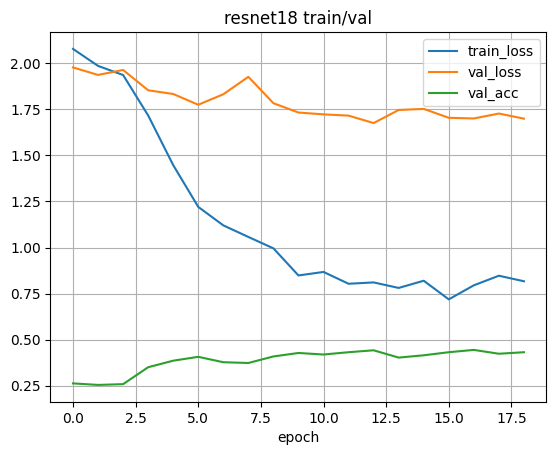

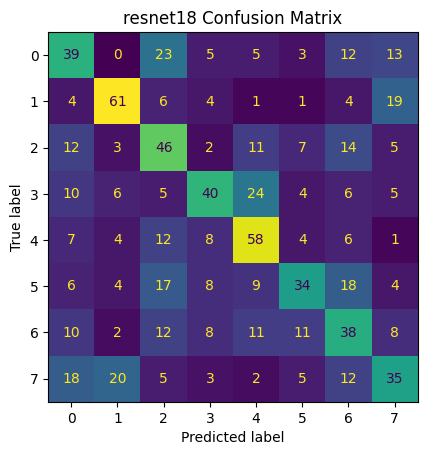


==== Training resnet50 ====
[resnet50] Device: cuda | Train 2720 | Val 479 | Test 800
[resnet50] Batch 32 | Steps/epoch: train=85 val=15
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


[resnet50] Epoch 1/30 (train):   0%|          | 0/85 [00:00<?, ?it/s]

[resnet50] Epoch 1/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[resnet50] Ep 01/30 | Train 2.0303 | Val 2.0058 | Acc 0.251 | F1 0.205 | κ 0.147 | α 0.117 | ROC-AUC 0.681 | PR-AUC 0.257 || RMSE(V 0.446, A 0.379) | CCC(V 0.079, A 0.029) | Epoch 27.2s (~100.1 samples/s)


...

[resnet50] Epoch 16/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[resnet50] Ep 16/30 | Train 0.7077 | Val 1.8407 | Acc 0.395 | F1 0.391 | κ 0.309 | α 0.308 | ROC-AUC 0.773 | PR-AUC 0.401 || RMSE(V 0.390, A 0.349) | CCC(V 0.369, A 0.229) | Epoch 45.3s (~60.1 samples/s)


[resnet50] Epoch 17/30 (train):   0%|          | 0/85 [00:00<?, ?it/s]

[resnet50] Epoch 17/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[resnet50] Ep 17/30 | Train 0.7894 | Val 1.7932 | Acc 0.413 | F1 0.412 | κ 0.330 | α 0.328 | ROC-AUC 0.781 | PR-AUC 0.413 || RMSE(V 0.390, A 0.353) | CCC(V 0.357, A 0.204) | Epoch 44.9s (~60.6 samples/s)
Early stopping at epoch 17


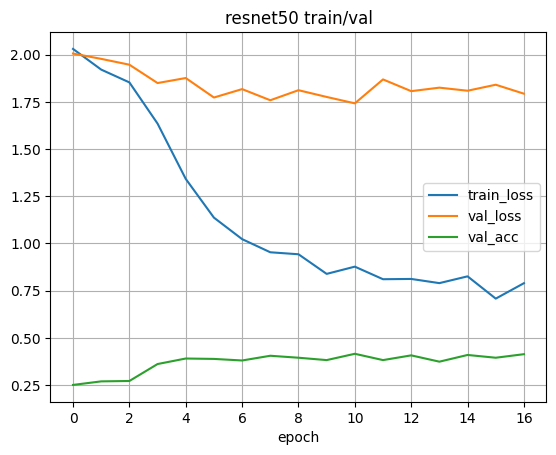

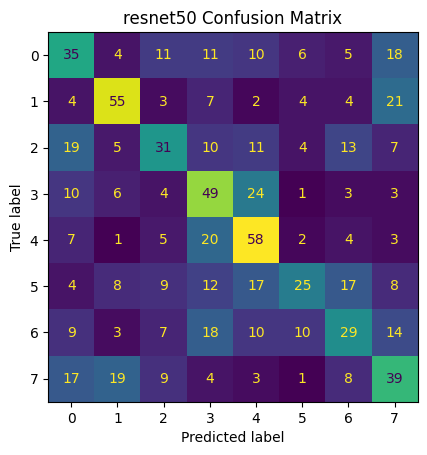


==== Training densenet121 ====
[densenet121] Device: cuda | Train 2720 | Val 479 | Test 800
[densenet121] Batch 32 | Steps/epoch: train=85 val=15
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 173MB/s]


[densenet121] Epoch 1/30 (train):   0%|          | 0/85 [00:00<?, ?it/s]

[densenet121] Epoch 1/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[densenet121] Ep 01/30 | Train 2.0755 | Val 2.1296 | Acc 0.157 | F1 0.099 | κ 0.054 | α -0.054 | ROC-AUC 0.670 | PR-AUC 0.244 || RMSE(V 0.453, A 0.379) | CCC(V 0.052, A 0.014) | Epoch 28.3s (~96.1 samples/s)


...

[densenet121] Epoch 24/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[densenet121] Ep 24/30 | Train 0.8177 | Val 1.6558 | Acc 0.474 | F1 0.472 | κ 0.399 | α 0.398 | ROC-AUC 0.829 | PR-AUC 0.496 || RMSE(V 0.386, A 0.339) | CCC(V 0.380, A 0.279) | Epoch 46.0s (~59.1 samples/s)


[densenet121] Epoch 25/30 (train):   0%|          | 0/85 [00:00<?, ?it/s]

[densenet121] Epoch 25/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[densenet121] Ep 25/30 | Train 0.8120 | Val 1.6483 | Acc 0.468 | F1 0.469 | κ 0.391 | α 0.391 | ROC-AUC 0.833 | PR-AUC 0.498 || RMSE(V 0.388, A 0.341) | CCC(V 0.363, A 0.265) | Epoch 45.6s (~59.7 samples/s)
Early stopping at epoch 25


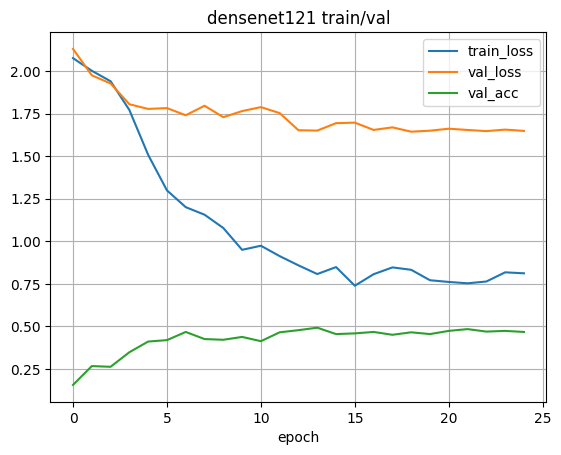

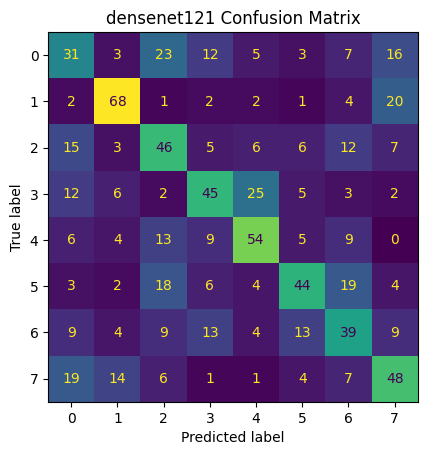


==== Training efficientnet_b0 ====
[efficientnet_b0] Device: cuda | Train 2720 | Val 479 | Test 800
[efficientnet_b0] Batch 32 | Steps/epoch: train=85 val=15
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 151MB/s]


[efficientnet_b0] Epoch 1/30 (train):   0%|          | 0/85 [00:00<?, ?it/s]

[efficientnet_b0] Epoch 1/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[efficientnet_b0] Ep 01/30 | Train 1.9869 | Val 1.9623 | Acc 0.269 | F1 0.254 | κ 0.169 | α 0.154 | ROC-AUC 0.695 | PR-AUC 0.269 || RMSE(V 0.451, A 0.377) | CCC(V 0.097, A 0.089) | Epoch 23.8s (~114.4 samples/s)


...

[efficientnet_b0] Epoch 29/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[efficientnet_b0] Ep 29/30 | Train 0.8183 | Val 1.7947 | Acc 0.397 | F1 0.399 | κ 0.309 | α 0.309 | ROC-AUC 0.781 | PR-AUC 0.409 || RMSE(V 0.403, A 0.352) | CCC(V 0.305, A 0.218) | Epoch 31.9s (~85.3 samples/s)


[efficientnet_b0] Epoch 30/30 (train):   0%|          | 0/85 [00:00<?, ?it/s]

[efficientnet_b0] Epoch 30/30 (val):   0%|          | 0/15 [00:00<?, ?it/s]

[efficientnet_b0] Ep 30/30 | Train 0.7848 | Val 1.7903 | Acc 0.403 | F1 0.407 | κ 0.317 | α 0.316 | ROC-AUC 0.782 | PR-AUC 0.407 || RMSE(V 0.405, A 0.352) | CCC(V 0.289, A 0.214) | Epoch 31.1s (~87.4 samples/s)


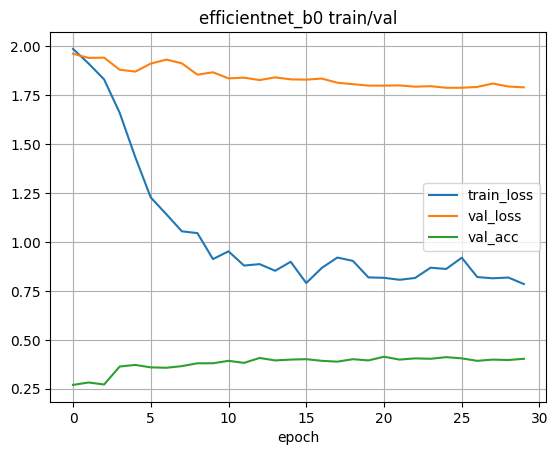

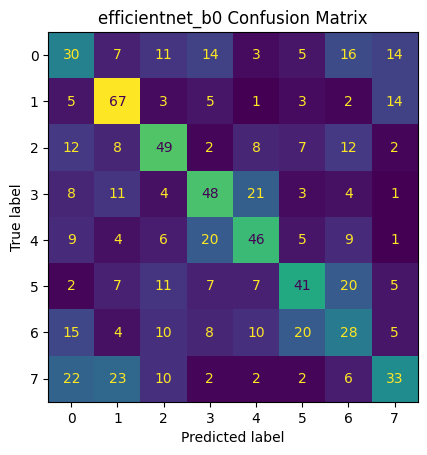


=== Test Comparison (sorted by Accuracy, then F1) ===
densenet121      Acc: 0.469  F1: 0.469  Kappa: 0.393
resnet18         Acc: 0.439  F1: 0.438  Kappa: 0.359
efficientnet_b0  Acc: 0.427  F1: 0.424  Kappa: 0.346
resnet50         Acc: 0.401  F1: 0.395  Kappa: 0.316


In [ ]:
backbones_to_try = [
    "resnet18",
    "resnet50",
    "densenet121",
    "efficientnet_b0",
]

results = {}
for bb in backbones_to_try:
    cfg = TrainConfig(
        img_root=IMGS,
        train_meta=train_meta_csv,
        test_meta=test_meta_csv,
        backbone=bb,
        epochs=30,
        batch_size=32,
        lr=1e-3,
        lambda_reg=0.25,
        num_workers=0,
        pretrained=True,
        mixup_alpha=0.2,
        # subset_train=1200, max_train_batches=80, max_val_batches=30,  # <- enable for quick smoke run
    )
    print(f"\n==== Training {bb} ====")
    _, res = train_one(cfg)
    results[bb] = res

# Save & show comparison
with open(os.path.join(SAVE_DIR, "comparison_multi.json"), "w") as f:
    json.dump(results, f, indent=2)

rows = []
for bb, res in results.items():
    cls = res["classification"]
    rows.append((bb, cls["accuracy"], cls["f1_macro"], cls["cohen_kappa"]))
rows_sorted = sorted(rows, key=lambda x: (x[1], x[2]), reverse=True)

print("\n=== Test Comparison (sorted by Accuracy, then F1) ===")
for bb, acc, f1, kappa in rows_sorted:
    print(f"{bb:15s}  Acc: {acc:.3f}  F1: {f1:.3f}  Kappa: {kappa:.3f}")


## 8. Qualitative Results Analysis

Generating qualitative results by visualizing correctly classified, incorrectly classified, and borderline prediction cases for model analysis and interpretation.


Device: cpu
SAVE_DIR: /content/drive/MyDrive/deep_temp1_runs
ANN: /content/drive/MyDrive/Dataset/annotations
IMGS: /content/drive/MyDrive/Dataset/images
[META] Using existing: /content/drive/MyDrive/Dataset/annotations/train_meta.csv and /content/drive/MyDrive/Dataset/annotations/test_meta.csv
[DATA] Test samples: 800
[CKPT] Loading: /content/drive/MyDrive/deep_temp1_runs/best_densenet121.pth
[CKPT] Backbone: densenet121
[OUT] Saved per-image predictions: /content/drive/MyDrive/deep_temp1_runs/qualitative_predictions.csv
[OUT] Saved figure: /content/drive/MyDrive/deep_temp1_runs/densenet121_correct.png


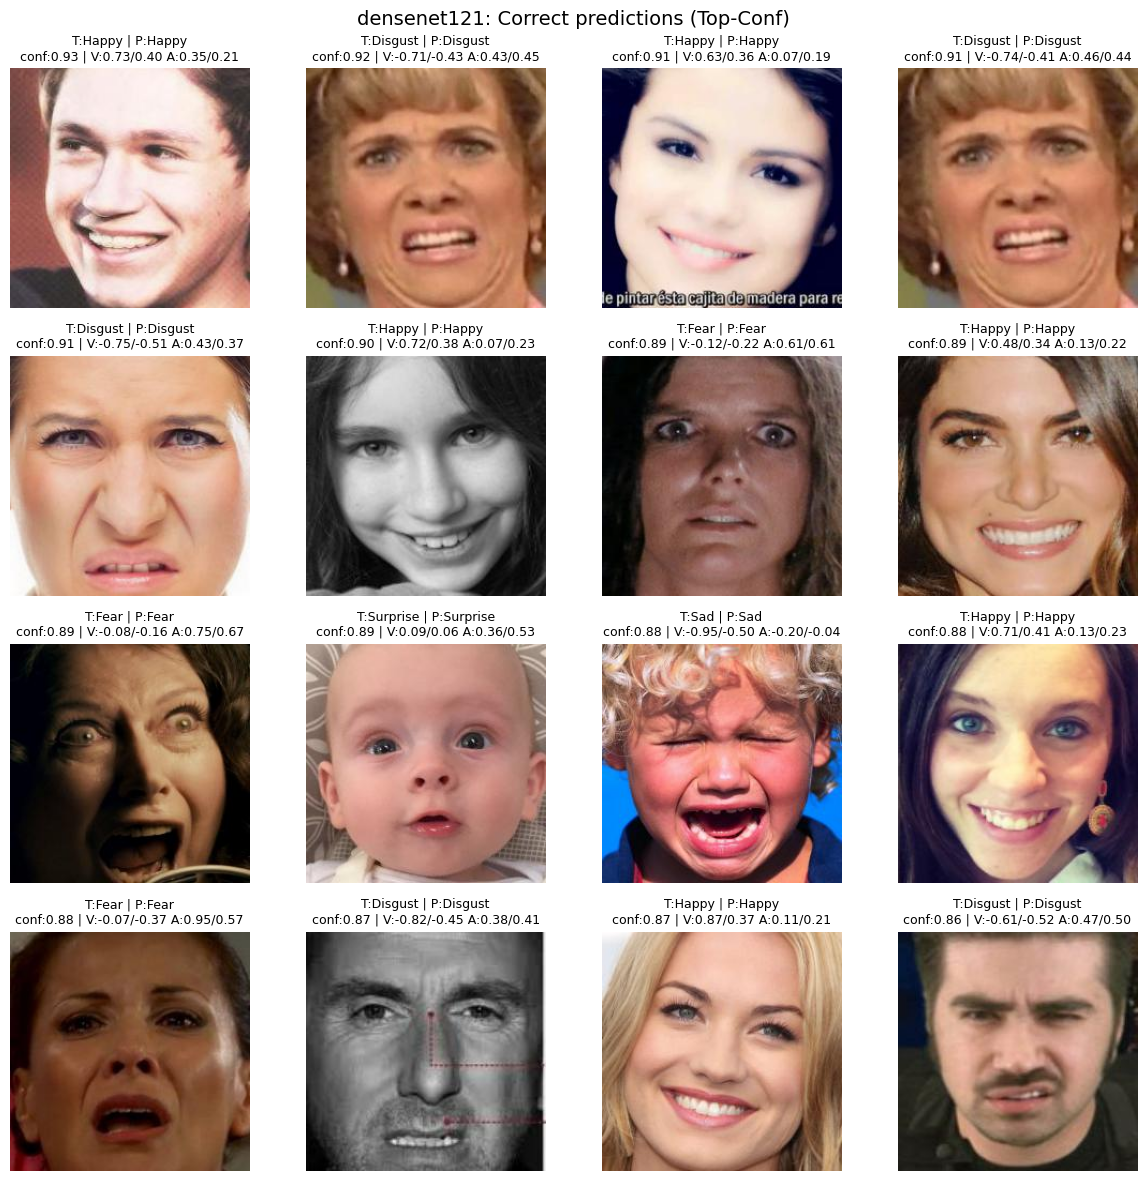

[OUT] Saved figure: /content/drive/MyDrive/deep_temp1_runs/densenet121_wrong.png


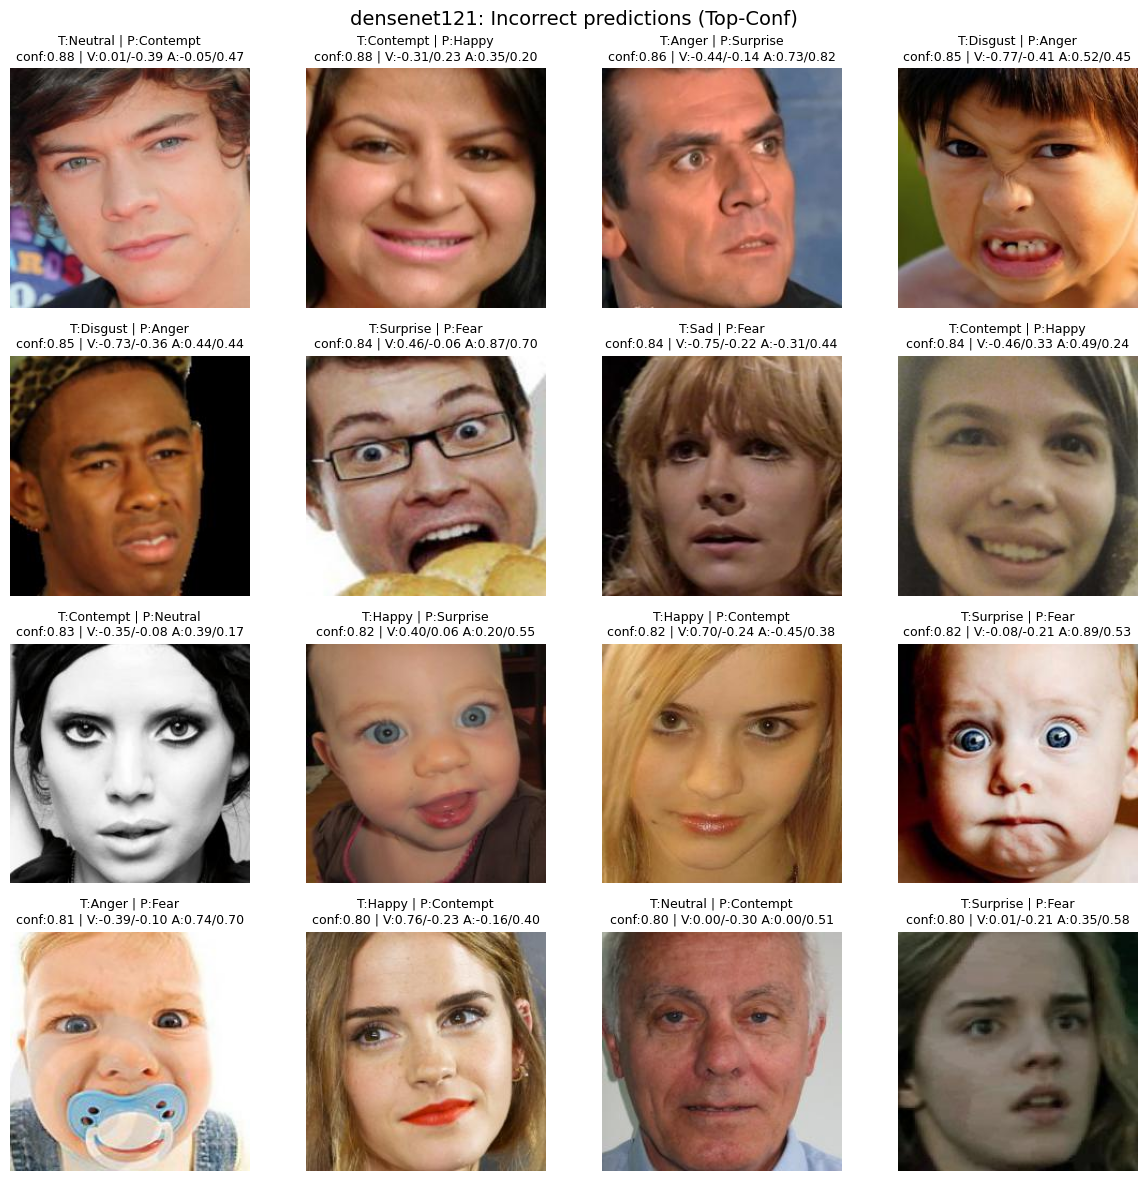

[OUT] Saved figure: /content/drive/MyDrive/deep_temp1_runs/densenet121_borderline.png


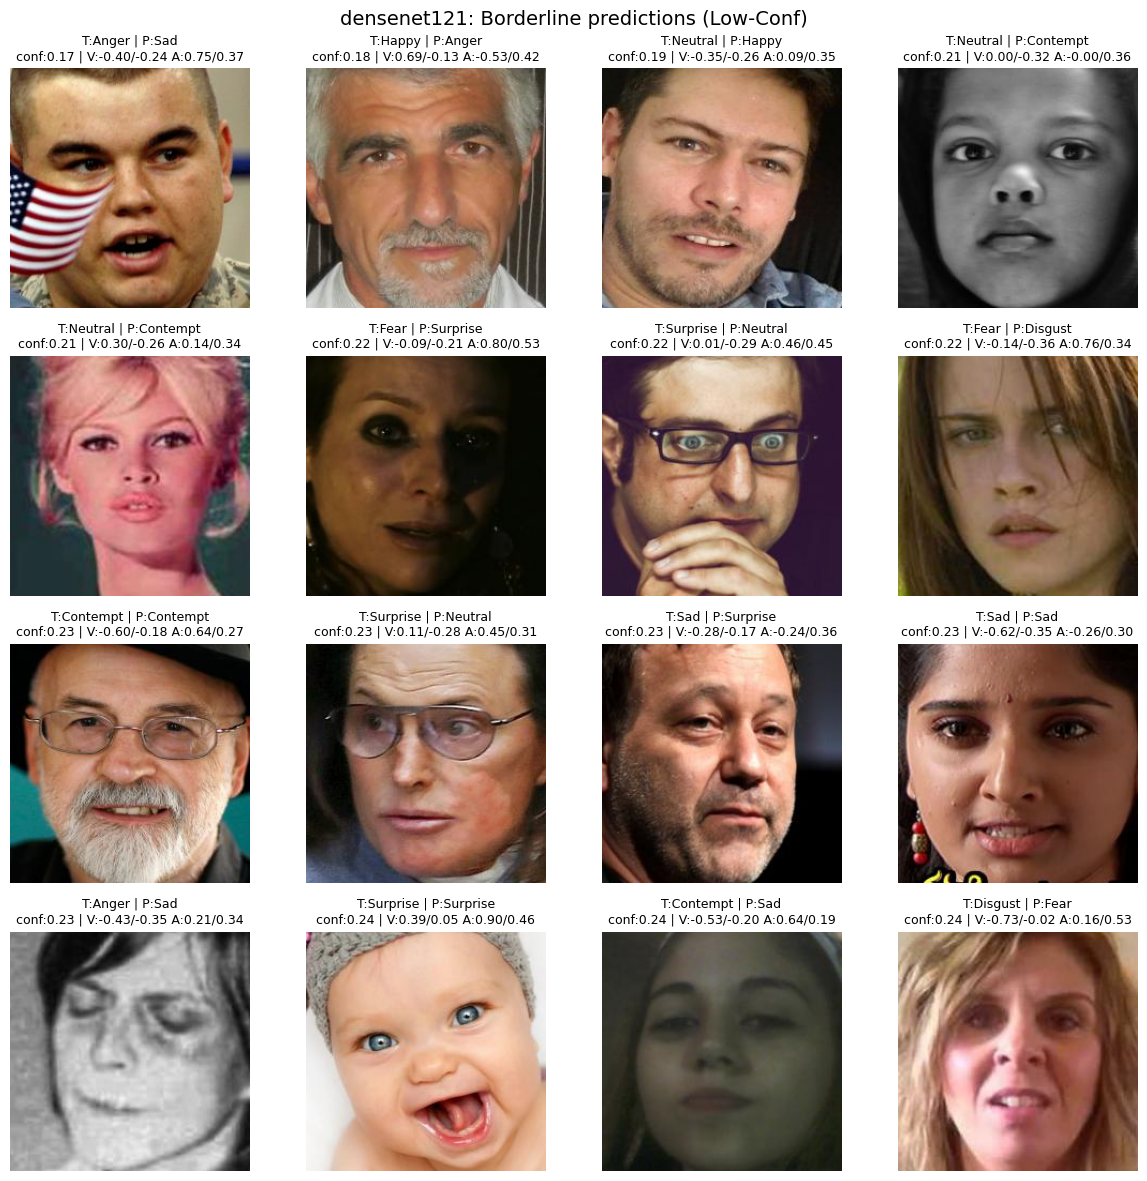


Done. Add these three PNGs + the CSV to your report:
- /content/drive/MyDrive/deep_temp1_runs/densenet121_correct.png
- /content/drive/MyDrive/deep_temp1_runs/densenet121_wrong.png
- /content/drive/MyDrive/deep_temp1_runs/densenet121_borderline.png
- /content/drive/MyDrive/deep_temp1_runs/qualitative_predictions.csv


In [7]:
# =========================
# Qualitative results — no retraining (CPU-safe)
# =========================
import os, glob, re, json, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split

# ---- Use your paths exactly as provided
ROOT = "/content/drive/MyDrive/Dataset"
ANN  = os.path.join(ROOT, "annotations")
IMGS = os.path.join(ROOT, "images")

SAVE_DIR = "/content/drive/MyDrive/deep_temp1_runs"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("SAVE_DIR:", SAVE_DIR)
print("ANN:", ANN)
print("IMGS:", IMGS)

# -------------------------
# 1) Build meta CSVs if missing
# -------------------------
def find_image_recursive(img_dir: str, stem: str):
    # Try common extensions, then fallback to recursive glob
    for ext in (".jpg",".jpeg",".png",".bmp",".webp",".JPG",".PNG",".JPEG",".BMP",".WEBP"):
        p = os.path.join(img_dir, stem + ext)
        if os.path.isfile(p):
            return p
    hits = glob.glob(os.path.join(img_dir, "**", stem + ".*"), recursive=True)
    return hits[0] if hits else None

def build_meta_from_npy(ann_dir: str, img_dir: str, out_dir: str, test_size=0.2, seed=42):
    exp_files = glob.glob(os.path.join(ann_dir, "*_exp.npy"))
    if len(exp_files) == 0:
        raise FileNotFoundError("No *_exp.npy found under annotations. Check ANN path.")

    id_pat = re.compile(r"(.+?)_exp\.npy$", re.IGNORECASE)
    ids = []
    for f in exp_files:
        m = id_pat.search(os.path.basename(f))
        if m: ids.append(m.group(1))
    ids = sorted(set(ids))

    rows, missing = [], []
    for sid in ids:
        exp_path = os.path.join(ann_dir, f"{sid}_exp.npy")
        val_path = os.path.join(ann_dir, f"{sid}_val.npy")
        aro_path = os.path.join(ann_dir, f"{sid}_aro.npy")
        lnd_path = os.path.join(ann_dir, f"{sid}_lnd.npy")
        img_path = find_image_recursive(img_dir, sid)

        if not (os.path.isfile(exp_path) and os.path.isfile(val_path) and os.path.isfile(aro_path) and img_path):
            missing.append(sid); continue

        def load_scalar(pth):
            arr = np.load(pth, allow_pickle=True)
            if np.isscalar(arr): return float(arr)
            try: return float(arr.item())
            except: return float(np.ravel(arr)[0])

        try:
            exp = int(load_scalar(exp_path))
            val = float(load_scalar(val_path))
            aro = float(load_scalar(aro_path))
        except Exception:
            continue

        rows.append({
            "id": sid,
            "filename": os.path.relpath(img_path, start=img_dir).replace("\\","/"),
            "expression": exp,
            "valence": val,
            "arousal": aro,
            "landmarks_path": (f"{sid}_lnd.npy" if os.path.isfile(lnd_path) else "")
        })

    if len(rows) == 0:
        raise RuntimeError("Could not index any samples — check filenames/stems in images vs annotations.")

    df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
    # Filter uncertain/no-face values
    df = df[(df["valence"] > -2) & (df["arousal"] > -2)].reset_index(drop=True)

    train_df, test_df = train_test_split(
        df, test_size=test_size, random_state=42,
        stratify=df["expression"] if df["expression"].nunique()>1 else None
    )

    Path(out_dir).mkdir(parents=True, exist_ok=True)
    train_csv = os.path.join(out_dir, "train_meta.csv")
    test_csv  = os.path.join(out_dir, "test_meta.csv")
    train_df.to_csv(train_csv, sep=";", index=False)
    test_df.to_csv(test_csv, sep=";", index=False)
    print(f"[META] Wrote: {train_csv} and {test_csv}")
    return train_csv, test_csv

train_meta_csv = os.path.join(ANN, "train_meta.csv")
test_meta_csv  = os.path.join(ANN, "test_meta.csv")

rebuilt = False
if not (os.path.isfile(train_meta_csv) and os.path.isfile(test_meta_csv)):
    print("[WARN] train_meta.csv or test_meta.csv not found — rebuilding from .npy …")
    train_meta_csv, test_meta_csv = build_meta_from_npy(ANN, IMGS, ANN)
    rebuilt = True
else:
    print("[META] Using existing:", train_meta_csv, "and", test_meta_csv)

# -------------------------
# 2) Dataset + transforms (val/test only)
# -------------------------
class AffectDataset(Dataset):
    def __init__(self, img_root: str, meta_csv: str, transform=None):
        self.img_root = img_root
        self.df = pd.read_csv(meta_csv, sep=';')
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_root, row["filename"])).convert("RGB")
        if self.transform: img = self.transform(img)
        y_cls = int(row["expression"])
        y_va  = np.array([row["valence"], row["arousal"]], dtype=np.float32)
        return img, torch.tensor(y_cls, dtype=torch.long), torch.tensor(y_va, dtype=torch.float32), row["filename"]

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

test_ds = AffectDataset(IMGS, test_meta_csv, transform=val_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
print(f"[DATA] Test samples: {len(test_ds)}")

# -------------------------
# 3) Model (must match training graph)
# -------------------------
class MultiHeadNet(nn.Module):
    def __init__(self, backbone: str = "resnet18", num_classes: int = 8, drop=0.2, pretrained: bool = False):
        super().__init__()
        self.backbone_name = backbone
        # Use no pretraining here to avoid any downloads during inference
        w = None
        if backbone == "resnet18":
            base = models.resnet18(weights=w)
            feat_dim = base.fc.in_features
            base.fc = nn.Identity()
        elif backbone == "resnet50":
            base = models.resnet50(weights=w)
            feat_dim = base.fc.in_features
            base.fc = nn.Identity()
        elif backbone == "densenet121":
            base = models.densenet121(weights=w)
            feat_dim = base.classifier.in_features
            base.classifier = nn.Identity()
        elif backbone == "efficientnet_b0":
            base = models.efficientnet_b0(weights=w)
            feat_dim = base.classifier[-1].in_features
            base.classifier = nn.Identity()
        else:
            raise ValueError("Unknown backbone in checkpoint; supported: resnet18, resnet50, densenet121, efficientnet_b0")

        self.backbone = base
        # heads as in training script
        self.cls_head = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(feat_dim, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(feat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        feats = self.backbone(x)
        logits = self.cls_head(feats)
        va = self.reg_head(feats)
        return logits, va

# -------------------------
# 4) Find & load a checkpoint
# -------------------------
def find_best_checkpoint(save_dir: str):
    # Prefer files named like best_*.pth; else pick latest .pth
    bests = sorted(glob.glob(os.path.join(save_dir, "best_*.pth")))
    if bests:
        return bests[0]  # if multiple, you can change selection
    allpth = sorted(glob.glob(os.path.join(save_dir, "*.pth")), key=os.path.getmtime, reverse=True)
    return allpth[0] if allpth else None

ckpt_path = find_best_checkpoint(SAVE_DIR)
if ckpt_path is None:
    raise FileNotFoundError(
        f"No checkpoint (.pth) found in {SAVE_DIR}. "
        "Train at least one model first so we can load it for qualitative results."
    )

print("[CKPT] Loading:", ckpt_path)
ckpt = torch.load(ckpt_path, map_location=DEVICE)
cfg_loaded = ckpt.get("cfg", {})
backbone_name = cfg_loaded.get("backbone", "resnet18")
print("[CKPT] Backbone:", backbone_name)

model = MultiHeadNet(backbone=backbone_name, pretrained=False).to(DEVICE)
model.load_state_dict(ckpt["state_dict"], strict=True)
model.eval()

# -------------------------
# 5) Inference on test set + collect predictions
# -------------------------
all_rows = []
with torch.no_grad():
    for xb, yb_cls, yb_va, fn in test_loader:
        xb = xb.to(DEVICE)
        logits, va = model(xb)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        for i in range(len(fn)):
            all_rows.append({
                "filename": fn[i],
                "y_true": int(yb_cls[i].item()),
                "y_pred": int(preds[i]),
                "conf": float(probs[i, preds[i]]),
                "v_true": float(yb_va[i,0].item()),
                "a_true": float(yb_va[i,1].item()),
                "v_pred": float(va[i,0].cpu().item()),
                "a_pred": float(va[i,1].cpu().item())
            })

pred_df = pd.DataFrame(all_rows)
pred_csv = os.path.join(SAVE_DIR, "qualitative_predictions.csv")
pred_df.to_csv(pred_csv, index=False)
print(f"[OUT] Saved per-image predictions: {pred_csv}")

# -------------------------
# 6) Pick qualitative samples (correct, wrong, borderline)
# -------------------------
def pick_samples(df, kind="correct", k=16):
    df = df.copy()
    if kind == "correct":
        df = df[df.y_true == df.y_pred].sort_values("conf", ascending=False)
    elif kind == "wrong":
        df = df[df.y_true != df.y_pred].sort_values("conf", ascending=False)
    elif kind == "borderline":
        df = df.sort_values("conf", ascending=True)
    else:
        raise ValueError("kind must be one of: correct, wrong, borderline")
    return df.head(k)

samples = {
    "correct": pick_samples(pred_df, "correct", 16),
    "wrong": pick_samples(pred_df, "wrong", 16),
    "borderline": pick_samples(pred_df, "borderline", 16),
}

# -------------------------
# 7) Helper to plot grids
# -------------------------
idx2label = {
    0:"Neutral",1:"Happy",2:"Sad",3:"Surprise",4:"Fear",5:"Disgust",6:"Anger",7:"Contempt"
}

def show_grid(df_subset, title, imgs_root=IMGS, rows=4, cols=4, figsize=(12,12), save_name=None):
    n = len(df_subset)
    rows = min(rows, math.ceil(n/cols)) if n>0 else rows
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(rows, cols)
    for ax in axes.ravel(): ax.axis("off")

    for i, (_, r) in enumerate(df_subset.iterrows()):
        if i >= rows*cols: break
        ax = axes[i//cols, i%cols]
        img_path = os.path.join(imgs_root, r["filename"])
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            continue
        ax.imshow(img)
        t_lbl = idx2label.get(int(r["y_true"]), str(int(r["y_true"])))
        p_lbl = idx2label.get(int(r["y_pred"]), str(int(r["y_pred"])))
        ax.set_title(f"T:{t_lbl} | P:{p_lbl}\nconf:{r['conf']:.2f} | V:{r['v_true']:.2f}/{r['v_pred']:.2f} A:{r['a_true']:.2f}/{r['a_pred']:.2f}",
                     fontsize=9)
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_name:
        outp = os.path.join(SAVE_DIR, save_name)
        plt.savefig(outp, bbox_inches="tight", dpi=150)
        print(f"[OUT] Saved figure: {outp}")
    plt.show()

# -------------------------
# 8) Render & save the three panels
# -------------------------
show_grid(samples["correct"],   f"{backbone_name}: Correct predictions (Top-Conf)", save_name=f"{backbone_name}_correct.png")
show_grid(samples["wrong"],     f"{backbone_name}: Incorrect predictions (Top-Conf)", save_name=f"{backbone_name}_wrong.png")
show_grid(samples["borderline"],f"{backbone_name}: Borderline predictions (Low-Conf)", save_name=f"{backbone_name}_borderline.png")

print("\nDone. Add these three PNGs + the CSV to your report:")
print(f"- {os.path.join(SAVE_DIR, f'{backbone_name}_correct.png')}")
print(f"- {os.path.join(SAVE_DIR, f'{backbone_name}_wrong.png')}")
print(f"- {os.path.join(SAVE_DIR, f'{backbone_name}_borderline.png')}")
print(f"- {pred_csv}")
